In [3]:
import numpy as np
print(np.random.rand(3))
print(np.random.rand(3))
np.random.seed(42)
a = np.random.rand(3)
np.random.seed(42)
b = np.random.rand(3)
print(np.array_equal(a,b))

[0.566146   0.27259603 0.81190732]
[0.88056533 0.50791906 0.72544746]
True


In [6]:
print(np.random.rand(2,3))
print(np.random.rand(2,3).round(3))
print(np.random.randint(0,10,size=(2,3)))

[[0.13949386 0.29214465 0.36636184]
 [0.45606998 0.78517596 0.19967378]]
[[0.514 0.592 0.046]
 [0.608 0.171 0.065]]
[[3 8 1]
 [9 8 9]]


In [13]:
x = np.random.normal(loc=10,scale=2,size=10000)
print(x.mean().round(2),x.std().round(2))
u = np.random.uniform(-1,1,size=10000)
print(u.mean().round(3))
rng = np.random.default_rng(42)
y = rng.normal(10,2,10000)
print(y.mean().round(2),y.std().round(2))

10.0 2.0
0.016
9.98 2.01


In [15]:
arr = np.array(['A','B','C','D','E'])
rng = np.random.default_rng(42)
print(rng.choice(arr,3,replace=True))
print(rng.choice(arr,3,replace=False))
print(rng.choice(arr,10,p=[0.5,.1,.1,.1,.2]))
shuffled = rng.permutation(arr)
print(shuffled)
rng.shuffle(arr)
print(arr)
M = np.arange(12).reshape(4,3)
rng.shuffle(M)
print(M)

['A' 'D' 'D']
['E' 'D' 'B']
['A' 'E' 'D' 'D' 'A' 'A' 'A' 'E' 'C' 'E']
['B' 'A' 'E' 'C' 'D']
['B' 'A' 'E' 'D' 'C']
[[ 6  7  8]
 [ 3  4  5]
 [ 9 10 11]
 [ 0  1  2]]


In [16]:
N = 1_000_000
rng = np.random.default_rng(42)
points = rng.uniform(-1,1,size=(N,2))
r2 = (points ** 2).sum(axis=1)
inside = (r2 <= 1).sum()
pi_est = 4 * inside / N
print(f"π ≈ {pi_est:.6f}, 误差 {abs(pi_est - np.pi):.6f}")

π ≈ 3.143256, 误差 0.001663


In [25]:
a = np.array([1,2,3])
print(a.dtype)
print(a.astype(np.float32).dtype)
x = np.array([120],dtype=np.int8)
print(x+np.array([10],dtype=np.int8))
big64 = np.zeros(1000,dtype=np.float64)
big32 = np.zeros(1000,dtype=np.float32)
print(big64.nbytes,big32.nbytes)

int64
float32
[-126]
8000 4000


In [30]:
a = np.array([1.0,2.0,np.nan,4.0])
print(a+1)
print(a.sum(),a.mean())
print(np.nansum(a),np.nanmean(a))
mask = np.isnan(a)
print(mask)
a_filled = np.where(np.isnan(a),0,a)
print(a_filled)
print(np.array([1.0]) / 0)
print(np.array([0.0]) / 0)

[ 2.  3. nan  5.]
nan nan
7.0 2.3333333333333335
[False False  True False]
[1. 2. 0. 4.]
[inf]
[nan]


C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_34712\854586076.py:9: RuntimeWarning: divide by zero encountered in divide
  print(np.array([1.0]) / 0)
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_34712\854586076.py:10: RuntimeWarning: invalid value encountered in divide
  print(np.array([0.0]) / 0)


In [33]:
data = np.arange(12).reshape(4,3).astype(float)
np.savetxt('data.csv',data,delimiter=',',fmt='%.2f',header='c1,c2,c3',comments='')
loaded = np.loadtxt('data.csv',delimiter=',',skiprows=1)
print(np.array_equal(data,loaded))
cols = np.loadtxt('data.csv',delimiter=',',skiprows=1,usecols=(0,2))
print(cols)

True
[[ 0.  2.]
 [ 3.  5.]
 [ 6.  8.]
 [ 9. 11.]]


In [35]:
np.save('data.npy',data)
restored = np.load('data.npy')
print(restored.shape,restored.dtype)
np.savez('bundle.npz',X=data,y=np.arange(4))
bag = np.load('bundle.npz')
print(bag.files)
print(bag['y'])
bag.close()
np.savez_compressed('bundle.npz',X=data,y=np.arange(4))
mm = np.memmap('big.dat',dtype='float64',mode='w+',shape=(1000,1000))
mm[:3,:3] = np.eye(3)
mm.flush()
print(mm[:3,:3])
del mm

(4, 3) float64
['X', 'y']
[0 1 2 3]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


Using device:cuda
Epoch [10/50], Train Loss: 0.6716, Val Loss: 0.7085, Acc: 0.5050
Epoch [20/50], Train Loss: 0.6611, Val Loss: 0.7202, Acc: 0.4750
Epoch [30/50], Train Loss: 0.6518, Val Loss: 0.7270, Acc: 0.4650
Epoch [40/50], Train Loss: 0.6436, Val Loss: 0.7338, Acc: 0.4600
Epoch [50/50], Train Loss: 0.6362, Val Loss: 0.7405, Acc: 0.4700
训练完成！


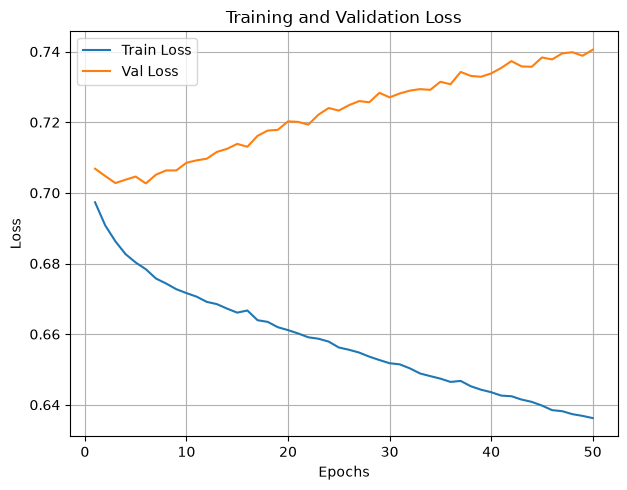

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
import matplotlib.pyplot as plt
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
INPUT_FEATURES = 10
NUM_CLASSES = 2
TRAIN_RATIO = 0.8
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:{device}')
class RandomDataset(Dataset):
    def __init__(self,num_samples=1000,input_dim=10,num_classes=2):
        self.X = torch.randn(num_samples,input_dim)
        self.y = torch.randint(0,num_classes,(num_samples,))
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]
full_dataset = RandomDataset(num_samples=1000,input_dim=INPUT_FEATURES,num_classes=NUM_CLASSES)
train_size = int(TRAIN_RATIO * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset,val_dataset = random_split(full_dataset,[train_size,val_size])
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
class SimpleNN(nn.Module):
    def __init__(self,input_dim,hidden_dim,num_classes):
        super(SimpleNN,self).__init__()
        self.fc1 = nn.Linear(input_dim,hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim,num_classes)
    def forward(self,x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out
model = SimpleNN(input_dim=INPUT_FEATURES,hidden_dim=32,num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=LEARNING_RATE)
history = {
    'train_loss':[],
    'val_loss':[],
    'val_accuracy':[],
    'val_precision':[],
    'val_recall':[]
}
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    for inputs,labels in train_loader:
        inputs,labels = inputs.to(device),labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
    epoch_train_loss = running_train_loss / len(train_dataset)
    history['train_loss'].append(epoch_train_loss)
    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs,labels in val_loader:
            inputs,labels = inputs.to(device),labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs,labels)
            running_val_loss += loss.item() * inputs.size(0)
            _,predicted = torch.max(outputs.data,1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_val_loss = running_val_loss / len(val_dataset)
    accuracy = accuracy_score(all_labels,all_preds)
    precision = precision_score(all_labels,all_preds,average='macro',zero_division=0)
    recall = recall_score(all_labels,all_preds,average='macro',zero_division=0)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(accuracy)
    history['val_precision'].append(precision)
    history['val_recall'].append(recall)
    if (epoch+1) % 10 == 0:
         print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Acc: {accuracy:.4f}")
print("训练完成！")
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1,EPOCHS+1),history['train_loss'],label='Train Loss')
plt.plot(range(1,EPOCHS+1),history['val_loss'],label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()